# 05 – PPML: Mô hình Gravity Chính (Poisson Pseudo-Maximum Likelihood)

**Pipeline stage:** Econometric Modeling → PPML – Mô hình chính

**Lý do sử dụng PPML** (Silva & Tenreyro 2005):
- Xử lý **zero flows** trong dữ liệu di cư (log-linear không dùng được khi y=0)
- Robust với **heteroscedasticity** trong multiplicative error
- Ước lượng được **biến time-invariant** (dist, colony, language) – khắc phục hạn chế FEM
- Dùng **Origin + Destination FE** để kiểm soát Multilateral Resistance (Anderson & van Wincoop 2003)

**Kết quả từ notebook 04:**
- Hausman test p < 0.05 → FEM nhất quán hơn REM
- FEM R²_within ≈ 0.46 nhưng mất biến time-invariant
- → PPML là mô hình chính, FEM là baseline kinh tế lượng

**Output chính:** Bảng kết quả dạng **Table 2** (giống paper tham khảo).

## 0. Import thư viện & cấu hình

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','linearmodels','-q'])
    from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects

os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/tables',  exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi':120,'font.size':11,'font.family':'DejaVu Sans'})
SEED = 42
np.random.seed(SEED)
print('✅ Import OK')

✅ Import OK


## 1. Load & chuẩn bị dữ liệu

In [2]:
# data_clean_pca: migration > 0 (cho POLS/FEM/REM log-linear)
# data_ppml_pca : migration ≥ 0, kể cả zero flows (cho PPML)
df_clean = pd.read_csv('../data/processed/data_clean_pca.csv', low_memory=False)
df_ppml  = pd.read_csv('../data/processed/data_ppml_pca.csv',  low_memory=False)

print(f'data_clean : {df_clean.shape}  (migration > 0)')
print(f'data_ppml  : {df_ppml.shape}   (migration ≥ 0)')

data_clean : (9125, 80)  (migration > 0)
data_ppml  : (16250, 79)   (migration ≥ 0)


In [3]:
def apply_fixes(df, is_ppml=False):
    """Áp dụng các fix lỗi từ notebook 04."""
    d = df.copy()
    # Giới hạn mẫu 2000-2022 (CO2/PM2.5 chưa đủ dữ liệu sau 2022)
    d = d[d['year'].between(2000, 2022)].copy()
    # Với data_clean: chỉ giữ migration > 0
    if not is_ppml:
        d = d[d['migration'] > 0].copy()
        d['ln_migration'] = np.log(d['migration'])
    # Fix zeros → NaN trong các biến log
    bad_ln_cols = ['ln_co2_org','ln_pm25_org','ln_bandwidth_org']
    for col in bad_ln_cols:
        if col in d.columns:
            d.loc[d[col] < -20, col] = np.nan
            d.loc[d[col] == 0,  col] = np.nan
    d.loc[d.get('ln_internet_use_org', pd.Series(dtype=float)) == 0, 'ln_internet_use_org'] = np.nan
    return d

df_c = apply_fixes(df_clean, is_ppml=False)
df_p = apply_fixes(df_ppml,  is_ppml=True)

print(f'Sau fix – data_clean: {df_c.shape}')
print(f'Sau fix – data_ppml : {df_p.shape}')
print(f'  Zero migration trong ppml: {(df_p["migration"]==0).sum():,}')
print(f'  Non-zero migration      : {(df_p["migration"]>0).sum():,}')

Sau fix – data_clean: (8360, 80)
Sau fix – data_ppml : (14950, 79)
  Zero migration trong ppml: 6,590
  Non-zero migration      : 8,360


## 2. Đặc tả biến

Theo gravity model chuẩn (Tinbergen 1962; Anderson & van Wincoop 2003; Silva & Tenreyro 2005):

| Nhóm | Biến | Dấu kỳ vọng | Lý giải |
|------|------|------------|--------|
| **Kinh tế** | `ln_gdppc_org` | − | GDPpc cao → push factor yếu |
| | `ln_gdppc_des` | + | GDPpc cao → pull factor mạnh |
| **Dân số** | `ln_pop_org` | + | Pool di cư tiềm năng |
| | `ln_pop_des` | + | Cơ hội việc làm lớn hơn |
| **Chi phí** | `ln_dist` | − | Khoảng cách → tăng chi phí |
| **Văn hóa** | `comlang_off` | + | Ngôn ngữ chung → dễ hội nhập |
| | `contig` | + | Chung biên giới |
| | `colony` | + | Di sản thuộc địa → mạng lưới |
| **Bất ổn** | `inflation_org` | + | Lạm phát → push factor |
| **ICT** | `ln_internet_use_org` | + | Internet giảm chi phí tìm kiếm |
| **Thiên tai** | `ln_disaster_org` | + | Thiên tai → push factor môi trường |
| | `ln_disaster_des` | − | Thiên tai nước đến → kém hấp dẫn |

In [4]:
# ── Biến độc lập cốt lõi ──────────────────────────────────────────────────
CORE_VARS = [
    'ln_gdppc_org', 'ln_gdppc_des',      # Kinh tế
    'ln_pop_org',   'ln_pop_des',         # Dân số
    'ln_dist',                            # Chi phí địa lý
    'comlang_off',  'contig', 'colony',   # Văn hóa / lịch sử
]

# ── Biến mở rộng (đặc thù của đề tài) ─────────────────────────────────────
EXTENDED_VARS = CORE_VARS + [
    'inflation_org',         # Bất ổn kinh tế nước gốc
    'ln_internet_use_org',   # Số hóa / ICT
    'ln_disaster_org',       # Thiên tai nước gốc
    'ln_disaster_des',       # Thiên tai nước đến
]

DEP_VAR = 'migration'       # PPML dùng giá trị thô (không log)
DEP_LOG = 'ln_migration'    # POLS/FEM dùng log

print('Core vars    :', CORE_VARS)
print('Extended vars:', EXTENDED_VARS)

Core vars    : ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony']
Extended vars: ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony', 'inflation_org', 'ln_internet_use_org', 'ln_disaster_org', 'ln_disaster_des']


## 3. Hàm ước lượng PPML

PPML dùng **GLM Poisson với log link** và **Origin + Destination FE**.

```
migration_ij = exp(α_i + α_j + β·X_ij) · ε_ij
```

- `α_i` = origin FE (kiểm soát Outward Multilateral Resistance)
- `α_j` = destination FE (kiểm soát Inward Multilateral Resistance)
- SE dùng **HC3 (heteroscedasticity-robust)**

In [5]:
def run_ppml(data, dep, indep,
             add_origin_fe=True, add_dest_fe=True,
             add_year_fe=True, cov_type='HC3', verbose=True):
    """
    Ước lượng PPML (GLM Poisson).
    dep     : tên cột biến phụ thuộc (giá trị thô, không log)
    indep   : list biến độc lập (log-transformed)
    add_*_fe: thêm fixed effects tương ứng
    Trả về : (result, X_df, y_series)
    """
    d = data.copy()

    fe_cols = []

    if add_origin_fe:
        fe_o = pd.get_dummies(d['iso_o'], prefix='fe_o', drop_first=True).astype(float)
        d = pd.concat([d, fe_o], axis=1)
        fe_cols += fe_o.columns.tolist()

    if add_dest_fe:
        fe_d = pd.get_dummies(d['iso_d'], prefix='fe_d', drop_first=True).astype(float)
        d = pd.concat([d, fe_d], axis=1)
        fe_cols += fe_d.columns.tolist()

    if add_year_fe:
        fe_y = pd.get_dummies(d['year'], prefix='yr', drop_first=True).astype(float)
        d = pd.concat([d, fe_y], axis=1)
        fe_cols += fe_y.columns.tolist()

    all_cols = indep + fe_cols

    # 🔥 FIX
    X = d[all_cols].astype(float)
    X = X.loc[:, ~X.columns.duplicated()]   # remove duplicate
    y = d[dep].astype(float)

    mask = X.notna().all(axis=1) & y.notna()
    X_fit = X[mask]
    y_fit = y[mask]

    if verbose:
        print(f'  N obs = {len(y_fit):,} | Zero y = {(y_fit==0).sum():,}')

    glm = sm.GLM(y_fit, X_fit, family=sm.families.Poisson())
    res = glm.fit(method='irls', maxiter=200, cov_type=cov_type)

    return res, X_fit, y_fit


def ppml_coef_table(res, main_vars, label='PPML'):
    """Trích hệ số chính (bỏ FE dummies) và tính IRR."""
    params   = res.params[main_vars]
    se       = res.bse[main_vars]
    pvals    = res.pvalues[main_vars]
    ci       = res.conf_int().loc[main_vars]
    irr      = np.exp(params)
    irr_lo   = np.exp(ci.iloc[:,0])
    irr_hi   = np.exp(ci.iloc[:,1])
    tstat    = params / se
    stars    = pvals.apply(lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else '')))

    return pd.DataFrame({
        'model'    : label,
        'variable' : main_vars,
        'coef'     : params.values,
        'se'       : se.values,
        't_stat'   : tstat.values,
        'p_value'  : pvals.values,
        'IRR'      : irr.values,
        'IRR_lo'   : irr_lo.values,
        'IRR_hi'   : irr_hi.values,
        'stars'    : stars.values,
    })


def pseudo_r2(res):
    return round(1 - res.deviance / res.null_deviance, 4)


print('✅ Hàm PPML đã định nghĩa')

✅ Hàm PPML đã định nghĩa


## 4. Ước lượng PPML

Chạy 3 đặc tả:
- **PPML-1**: Core gravity (8 biến) + Origin/Dest/Year FE
- **PPML-2**: Extended (12 biến) + Origin/Dest/Year FE  ← **Mô hình chính**
- **PPML-3**: PPML-2 không có Year FE (robustness check)

In [6]:
print('=== PPML-1: Core Gravity ===')
res_p1, X_p1, y_p1 = run_ppml(df_p, DEP_VAR, CORE_VARS)
print()
print('=== PPML-2: Extended (Mô hình chính) ===')
res_p2, X_p2, y_p2 = run_ppml(df_p, DEP_VAR, EXTENDED_VARS)
print()
print('=== PPML-3: Extended, không có Year FE ===')
res_p3, X_p3, y_p3 = run_ppml(df_p, DEP_VAR, EXTENDED_VARS, add_year_fe=False)

=== PPML-1: Core Gravity ===
  N obs = 14,950 | Zero y = 6,590

=== PPML-2: Extended (Mô hình chính) ===
  N obs = 14,850 | Zero y = 6,542

=== PPML-3: Extended, không có Year FE ===
  N obs = 14,850 | Zero y = 6,542


In [7]:
# ── Trích bảng hệ số ──
tab_p1 = ppml_coef_table(res_p1, CORE_VARS,     'PPML-1 Core')
tab_p2 = ppml_coef_table(res_p2, EXTENDED_VARS, 'PPML-2 Extended')
tab_p3 = ppml_coef_table(res_p3, EXTENDED_VARS, 'PPML-3 No Year FE')

print('=== PPML-2 Extended (hệ số chính) ===')
print(tab_p2[['variable','coef','se','t_stat','p_value','IRR','stars']].to_string(index=False))

=== PPML-2 Extended (hệ số chính) ===
           variable    coef     se   t_stat  p_value    IRR stars
       ln_gdppc_org  0.3255 0.1159   2.8079   0.0050 1.3847   ***
       ln_gdppc_des  0.0612 0.1518   0.4035   0.6866 1.0632      
         ln_pop_org  0.4890 0.3259   1.5005   0.1335 1.6307      
         ln_pop_des  0.1350 0.3110   0.4340   0.6643 1.1445      
            ln_dist -0.5809 0.0267 -21.7761   0.0000 0.5594   ***
        comlang_off  0.9634 0.0568  16.9517   0.0000 2.6205   ***
             contig  1.2175 0.0656  18.5589   0.0000 3.3786   ***
             colony  0.7785 0.0514  15.1540   0.0000 2.1782   ***
      inflation_org  0.0056 0.0071   0.7950   0.4266 1.0056      
ln_internet_use_org  0.0712 0.0435   1.6381   0.1014 1.0738      
    ln_disaster_org -0.0185 0.0314  -0.5891   0.5558 0.9817      
    ln_disaster_des -0.0232 0.0334  -0.6955   0.4868 0.9770      


## 5. PPML-SUR: Hồi quy 2 giai đoạn (Kiểm soát tương quan chéo phương trình)

Theo Ghani et al. (2019) và Zellner (1962): **PPML-SUR** = phiên bản PPML của Seemingly Unrelated Regression.

**Quy trình 2 bước:**
1. Chạy PPML ban đầu → lấy **phần dư (residuals) Pearson**
2. Thêm phần dư vào mô hình chính như một covariable để kiểm soát cross-equation correlation

Trong ngữ cảnh đề tài (chỉ có phương trình di cư):
> Phần dư của PPML-2 được dùng như biến kiểm soát **unobserved common factors** giữa các cặp quốc gia.

In [8]:
# ── Bước 1: Lấy Pearson residuals từ PPML-2 ──────────────────────────────
pearson_resid_p2 = res_p2.resid_pearson
df_sur = df_p.copy()

# Ghép residuals vào df theo index của X_p2
resid_series = pd.Series(pearson_resid_p2, index=X_p2.index, name='ppml_resid')
df_sur = df_sur.join(resid_series, how='left')

print(f'Pearson residuals gắn vào df_sur: {df_sur["ppml_resid"].notna().sum():,} obs')
print(f'Resid mean={df_sur["ppml_resid"].mean():.4f}, std={df_sur["ppml_resid"].std():.4f}')

Pearson residuals gắn vào df_sur: 14,850 obs
Resid mean=5.8729, std=184.1145


In [9]:
# ── Bước 2: PPML-SUR = PPML-2 + ppml_resid ──────────────────────────────
EXTENDED_SUR = EXTENDED_VARS + ['ppml_resid']

print('=== PPML-SUR (2-stage) ===')
res_sur, X_sur, y_sur = run_ppml(df_sur, DEP_VAR, EXTENDED_SUR)

tab_sur = ppml_coef_table(res_sur, EXTENDED_VARS, 'PPML-SUR')  # bỏ ppml_resid khỏi bảng
print()
print('PPML-SUR main coefficients:')
print(tab_sur[['variable','coef','IRR','stars']].to_string(index=False))

=== PPML-SUR (2-stage) ===
  N obs = 14,850 | Zero y = 6,542

PPML-SUR main coefficients:
           variable    coef    IRR stars
       ln_gdppc_org  0.6988 2.0113   ***
       ln_gdppc_des -0.0611 0.9407      
         ln_pop_org  0.7479 2.1126   ***
         ln_pop_des -0.1902 0.8268      
            ln_dist -0.6715 0.5110   ***
        comlang_off  0.8003 2.2263   ***
             contig  1.2447 3.4721   ***
             colony  1.2551 3.5080   ***
      inflation_org  0.0034 1.0034      
ln_internet_use_org -0.0022 0.9978      
    ln_disaster_org -0.0140 0.9861      
    ln_disaster_des -0.0243 0.9760      


## 6. Tái tạo POLS & FEM từ kết quả Notebook 04

Để tổng hợp **Table 2** cần kết quả POLS và FEM. Chạy lại nhanh để lấy cùng format.

In [10]:
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
import statsmodels.api as sm
import pandas as pd
import numpy as np

# =========================
# 1. PANEL SETUP
# =========================
def make_panel(data):
    d = data.copy()
    d['pair_id'] = d['pair_id'].astype(str)
    d = d.set_index(['pair_id','year'])
    return d

panel_c = make_panel(df_c)

# =========================
# 2. CLEAN FUNCTION (QUAN TRỌNG)
# =========================
def clean_X(X):
    # remove duplicate columns
    X = X.loc[:, ~X.columns.duplicated()]
    
    # convert to numeric
    X = X.apply(pd.to_numeric, errors='coerce')
    
    # drop near-constant columns
    X = X.loc[:, X.std() > 1e-10]
    
    return X

# =========================
# 3. POLS
# =========================
pols_vars = EXTENDED_VARS

d_pols = panel_c[[DEP_LOG] + pols_vars].dropna()

X_pols = clean_X(d_pols[pols_vars])
y_pols = d_pols[DEP_LOG].loc[X_pols.index]

X_pols = sm.add_constant(X_pols)

pols_res = PooledOLS(y_pols, X_pols).fit(
    cov_type='clustered', cluster_entity=True
)

# =========================
# 4. FEM (FIX CHUẨN)
# =========================
# ❌ bỏ biến time-invariant
fem_vars = [v for v in EXTENDED_VARS if v not in ['ln_dist','comlang_off','contig','colony']]

d_fem = panel_c[[DEP_LOG] + fem_vars].dropna()

X_fem = clean_X(d_fem[fem_vars])
y_fem = d_fem[DEP_LOG].loc[X_fem.index]

# 👉 KHÔNG dùng year dummies thủ công nữa
fem_res = PanelOLS(
    y_fem,
    X_fem,
    entity_effects=True,
    time_effects=True   # 🔥 FIX QUAN TRỌNG
).fit(cov_type='clustered', cluster_entity=True)

# =========================
# 5. REM
# =========================
rem_vars = EXTENDED_VARS

d_rem = panel_c[[DEP_LOG] + rem_vars].dropna()

X_rem = clean_X(d_rem[rem_vars])
y_rem = d_rem[DEP_LOG].loc[X_rem.index]

X_rem = sm.add_constant(X_rem)

rem_res = RandomEffects(y_rem, X_rem).fit(
    cov_type='clustered', cluster_entity=True
)

# =========================
# 6. SAFE RANK CHECK (OPTIONAL)
# =========================
try:
    print("\nRank check FEM:")
    print("Rank:", np.linalg.matrix_rank(X_fem.values.astype(float)))
    print("Columns:", X_fem.shape[1])
except Exception as e:
    print("Rank check skipped:", e)

# =========================
# 7. OUTPUT
# =========================
print('\n' + '='*55)
print('MODEL COMPARISON')
print('='*55)

print('POLS N:', int(pols_res.nobs), '| R²:', round(float(pols_res.rsquared),4))
print('FEM  N:', int(fem_res.nobs),  '| R²_within:', round(float(fem_res.rsquared_within),4))
print('REM  N:', int(rem_res.nobs),  '| R²_overall:', round(float(rem_res.rsquared_overall),4))

print('PPML N:', len(y_p2), '| Pseudo R²:', pseudo_r2(res_p2))
print('PPML-SUR N:', len(y_sur), '| Pseudo R²:', pseudo_r2(res_sur))


Rank check FEM:
Rank: 8
Columns: 8

MODEL COMPARISON
POLS N: 8308 | R²: 0.5152
FEM  N: 8308 | R²_within: 0.0573
REM  N: 8308 | R²_overall: 0.2524
PPML N: 14850 | Pseudo R²: 0.8294
PPML-SUR N: 14850 | Pseudo R²: 0.949


## 7. Bảng kết quả tổng hợp – **Table 2: Gravity Model Regression Results**

Dạng bảng chuẩn học thuật, tương tự Ghani et al. (2019) Table 2.

**Cột:** Pooled OLS | FEM | REM | PPML | PPML-SUR  
**Hàng:** từng biến, SE trong ngoặc, stars ý nghĩa thống kê  
**Cuối bảng:** N, R², Pseudo R², Hausman test

In [11]:
def coef_star(coef, se, pval, fmt='.4f'):
    """Trả về chuỗi 'coef***' và '(se)'."""
    s = '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.1 else ''))
    return f'{coef:{fmt}}{s}', f'({se:{fmt}})'


def extract_lm(res, var):
    """Lấy coef/se/pval từ linearmodels result."""
    if var not in res.params.index:
        return None, None, None
    return float(res.params[var]), float(res.std_errors[var]), float(res.pvalues[var])


def extract_glm(res, var):
    """Lấy coef/se/pval từ statsmodels GLM result."""
    if var not in res.params.index:
        return None, None, None
    return float(res.params[var]), float(res.bse[var]), float(res.pvalues[var])


# ── Danh sách biến hiển thị trong bảng ──
TABLE_VARS = [
    ('ln_gdppc_org',       'GDPpc Nước gốc (ln)'),
    ('ln_gdppc_des',       'GDPpc Nước đến (ln)'),
    ('ln_pop_org',         'Dân số Nước gốc (ln)'),
    ('ln_pop_des',         'Dân số Nước đến (ln)'),
    ('ln_dist',            'Khoảng cách (ln)'),
    ('comlang_off',        'Ngôn ngữ chung'),
    ('contig',             'Biên giới chung'),
    ('colony',             'Thuộc địa chung'),
    ('inflation_org',      'Lạm phát Nước gốc'),
    ('ln_internet_use_org','Internet Nước gốc (ln)'),
    ('ln_disaster_org',    'Thiên tai Nước gốc (ln)'),
    ('ln_disaster_des',    'Thiên tai Nước đến (ln)'),
]

MODELS = {
    'Pooled OLS' : ('lm', pols_res),
    'FEM'        : ('lm', fem_res),
    'REM'        : ('lm', rem_res),
    'PPML'       : ('glm', res_p2),
    'PPML-SUR'   : ('glm', res_sur),
}

# ── Build bảng ──
rows = []
for var_code, var_label in TABLE_VARS:
    row = {'Biến': var_label}
    se_row = {'Biến': ''}
    for model_name, (mtype, mres) in MODELS.items():
        if mtype == 'lm':
            c, s, p = extract_lm(mres, var_code)
        else:
            c, s, p = extract_glm(mres, var_code)
        if c is None:
            row[model_name] = '–'
            se_row[model_name] = ''
        else:
            cv, sv = coef_star(c, s, p)
            row[model_name] = cv
            se_row[model_name] = sv
    rows.append(row)
    rows.append(se_row)

# ── Thêm hàng thống kê ──
def nobs_str(mtype, mres):
    try: return f"{int(mres.nobs):,}"
    except: return '–'

def r2_str(mtype, mres, which='overall'):
    try:
        if mtype == 'glm':
            return f"{1 - mres.deviance/mres.null_deviance:.4f}"
        if which == 'within':
            return f"{float(mres.rsquared_within):.4f}"
        return f"{float(mres.rsquared):.4f}"
    except: return '–'

stat_rows = [
    {'Biến': 'N'} | {m: nobs_str(t, r) for m, (t, r) in MODELS.items()},
    {'Biến': 'R² / Pseudo R²'} | {m: r2_str(t, r) for m, (t, r) in MODELS.items()},
    {'Biến': 'R² Within'} | {m: r2_str(t, r, 'within') for m, (t, r) in MODELS.items()},
    {'Biến': 'FE Origin'} | {m: ('✓' if m in ['PPML','PPML-SUR'] else ('✓' if m=='FEM' else '–'))
                            for m in MODELS},
    {'Biến': 'FE Dest'}   | {m: ('✓' if m in ['PPML','PPML-SUR'] else '–') for m in MODELS},
    {'Biến': 'FE Year'}   | {m: '✓' for m in MODELS},
]
rows.extend(stat_rows)

table2 = pd.DataFrame(rows)
print('=== TABLE 2: GRAVITY MODEL REGRESSION RESULTS ===')
print('Note: *** p<0.01  ** p<0.05  * p<0.10 | SE trong ngoặc (clustered/robust)')
print(table2.to_string(index=False))

=== TABLE 2: GRAVITY MODEL REGRESSION RESULTS ===
Note: *** p<0.01  ** p<0.05  * p<0.10 | SE trong ngoặc (clustered/robust)
                   Biến Pooled OLS        FEM        REM       PPML   PPML-SUR
    GDPpc Nước gốc (ln)   -0.2227*     0.1492  0.2456***  0.3255***  0.6988***
                          (0.1292)   (0.1284)   (0.0836)   (0.1159)   (0.1101)
    GDPpc Nước đến (ln)  1.1336***    -0.1490     0.0889     0.0612    -0.0611
                          (0.1120)   (0.1098)   (0.0745)   (0.1518)   (0.0866)
   Dân số Nước gốc (ln)  0.5278***  -1.2235**   0.2454**     0.4890  0.7479***
                          (0.0779)   (0.4825)   (0.1173)   (0.3259)   (0.2597)
   Dân số Nước đến (ln)  0.4859*** -1.5910***    0.1561*     0.1350    -0.1902
                          (0.0707)   (0.3723)   (0.0888)   (0.3110)   (0.2464)
       Khoảng cách (ln) -0.3490***          –    -0.0244 -0.5809*** -0.6715***
                          (0.0788)              (0.1045)   (0.0267)   (0.0116)
       

## 8. Xuất Table 2 đẹp (CSV + HTML)

In [12]:
# ── Lưu CSV ──
table2.to_csv('../output/tables/Table2_Gravity_Results.csv', index=False)
print('✅ Lưu: output/tables/Table2_Gravity_Results.csv')

# ── Hiển thị styled trong notebook ──
def highlight_stars(val):
    if isinstance(val, str):
        if '***' in val: return 'background-color: #fff3cd; font-weight: bold'
        if '**' in val:  return 'background-color: #d4edda'
        if '*' in val:   return 'background-color: #d1ecf1'
    return ''

styled = (table2.style
    .set_caption('Table 2: Gravity Model Regression Results')
    .applymap(highlight_stars, subset=list(MODELS.keys()))
    .set_properties(**{'text-align':'center', 'font-size':'11px'})
    .set_properties(subset=['Biến'], **{'text-align':'left', 'font-weight':'bold', 'min-width':'160px'})
    .set_table_styles([
        {'selector':'caption', 'props':[('font-size','14px'),('font-weight','bold'),
                                        ('text-align','center'),('padding','10px')]},
        {'selector':'th', 'props':[('background-color','#2c3e50'),('color','white'),
                                   ('text-align','center'),('padding','8px 12px')]},
        {'selector':'td', 'props':[('padding','5px 10px'),('border','1px solid #dee2e6')]},
        {'selector':'tr:nth-child(even)', 'props':[('background-color','#f8f9fa')]},
    ])
)

# Lưu HTML
with open('../output/tables/Table2_Gravity_Results.html','w',encoding='utf-8') as f:
    f.write(styled.to_html())
print('✅ Lưu: output/tables/Table2_Gravity_Results.html')

styled

✅ Lưu: output/tables/Table2_Gravity_Results.csv
✅ Lưu: output/tables/Table2_Gravity_Results.html


,Biến,Pooled OLS,FEM,REM,PPML,PPML-SUR
0,GDPpc Nước gốc (ln),-0.2227*,0.1492,0.2456***,0.3255***,0.6988***
1,,(0.1292),(0.1284),(0.0836),(0.1159),(0.1101)
2,GDPpc Nước đến (ln),1.1336***,-0.1490,0.0889,0.0612,-0.0611
3,,(0.1120),(0.1098),(0.0745),(0.1518),(0.0866)
4,Dân số Nước gốc (ln),0.5278***,-1.2235**,0.2454**,0.4890,0.7479***
5,,(0.0779),(0.4825),(0.1173),(0.3259),(0.2597)
6,Dân số Nước đến (ln),0.4859***,-1.5910***,0.1561*,0.1350,-0.1902
7,,(0.0707),(0.3723),(0.0888),(0.3110),(0.2464)
8,Khoảng cách (ln),-0.3490***,–,-0.0244,-0.5809***,-0.6715***
9,,(0.0788),,(0.1045),(0.0267),(0.0116)


## 9. Biểu đồ IRR (Incidence Rate Ratio) – PPML-2

**IRR = exp(β)**: nếu IRR > 1 → biến tăng 1 đơn vị làm di cư tăng; IRR < 1 → giảm.

Đây là cách trình bày kết quả PPML chuẩn trong tài liệu (thay vì hệ số log).

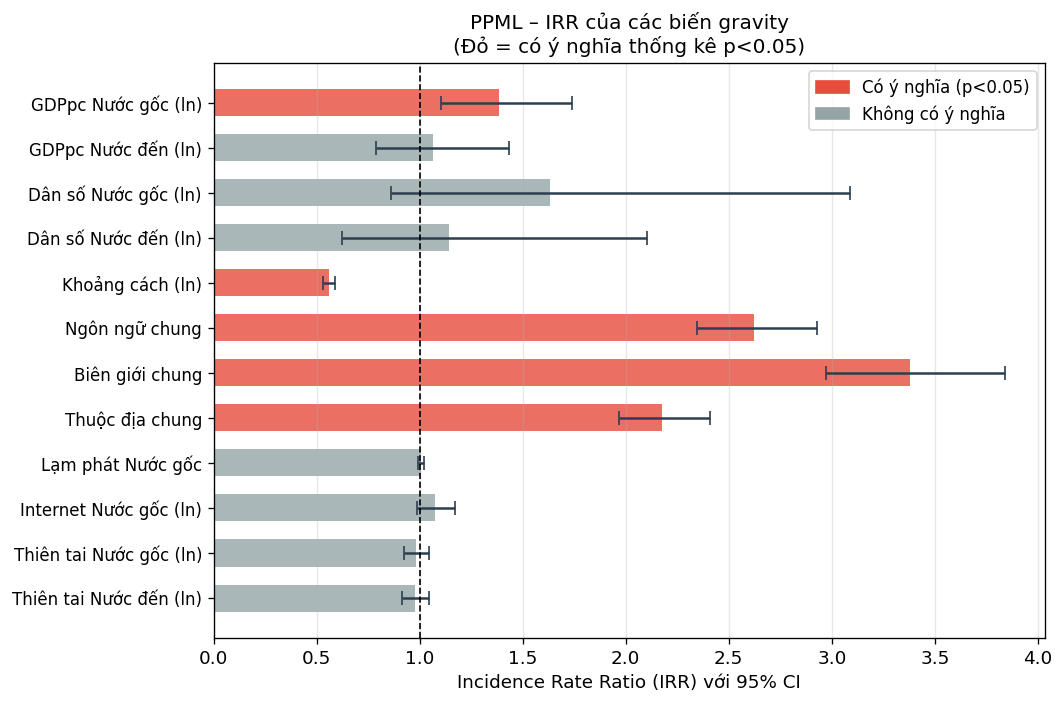

✅ Saved: output/figures/ppml_irr_plot.png


In [13]:
irr_df = tab_p2.copy()
irr_df['label'] = [v[1] for v in TABLE_VARS if v[0] in irr_df['variable'].values]

# Re-map labels
var_label_map = dict(TABLE_VARS)
irr_df['label'] = irr_df['variable'].map(var_label_map).fillna(irr_df['variable'])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in irr_df['p_value']]

ax.barh(range(len(irr_df)), irr_df['IRR'], color=colors, alpha=0.8, height=0.6)
ax.errorbar(
    irr_df['IRR'], range(len(irr_df)),
    xerr=[irr_df['IRR']-irr_df['IRR_lo'], irr_df['IRR_hi']-irr_df['IRR']],
    fmt='none', color='#2c3e50', linewidth=1.5, capsize=4
)
ax.axvline(1, color='black', linewidth=1, linestyle='--', label='IRR = 1 (no effect)')
ax.set_yticks(range(len(irr_df)))
ax.set_yticklabels(irr_df['label'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Incidence Rate Ratio (IRR) với 95% CI', fontsize=11)
ax.set_title('PPML – IRR của các biến gravity\n(Đỏ = có ý nghĩa thống kê p<0.05)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='Có ý nghĩa (p<0.05)'),
    Patch(color='#95a5a6', label='Không có ý nghĩa'),
], fontsize=10)

plt.tight_layout()
plt.savefig('../output/figures/ppml_irr_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/ppml_irr_plot.png')

## 10. So sánh PPML vs PPML-SUR – IRR side-by-side

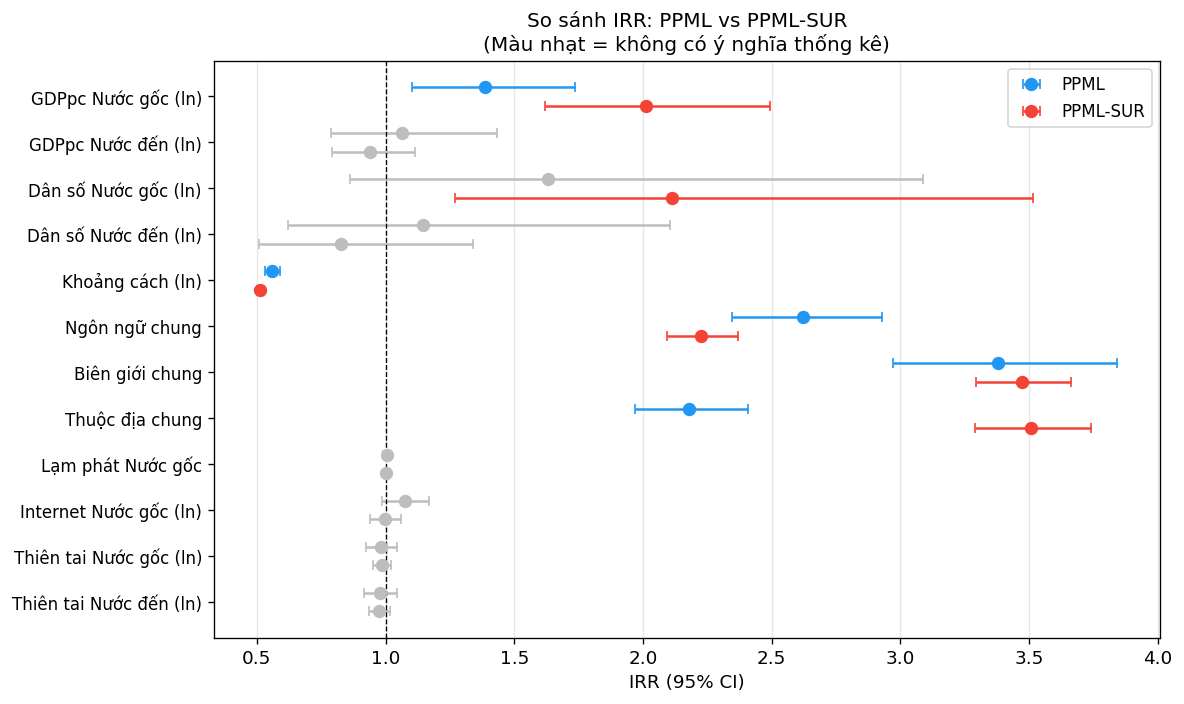

✅ Saved: output/figures/ppml_vs_sur_irr.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

var_label_map = dict(TABLE_VARS)
plot_vars = [v for v in EXTENDED_VARS if v in tab_p2['variable'].values]
n = len(plot_vars)
offset = 0.2

for i, var in enumerate(plot_vars):
    lbl = var_label_map.get(var, var)
    for tab, clr, lbl_m, off in [
        (tab_p2,  '#2196F3', 'PPML',     -offset),
        (tab_sur, '#F44336', 'PPML-SUR', +offset),
    ]:
        row = tab[tab['variable']==var]
        if row.empty: continue
        irr   = row['IRR'].values[0]
        irr_l = row['IRR_lo'].values[0]
        irr_h = row['IRR_hi'].values[0]
        pv    = row['p_value'].values[0]
        c     = clr if pv < 0.05 else '#BDBDBD'
        ax.errorbar(irr, i+off, xerr=[[irr-irr_l],[irr_h-irr]],
                    fmt='o', color=c, markersize=7, capsize=3, linewidth=1.5,
                    label=lbl_m if i==0 else '')

ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(n))
ax.set_yticklabels([var_label_map.get(v,v) for v in plot_vars], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('IRR (95% CI)', fontsize=11)
ax.set_title('So sánh IRR: PPML vs PPML-SUR\n(Màu nhạt = không có ý nghĩa thống kê)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../output/figures/ppml_vs_sur_irr.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/ppml_vs_sur_irr.png')

## 11. Chẩn đoán mô hình PPML

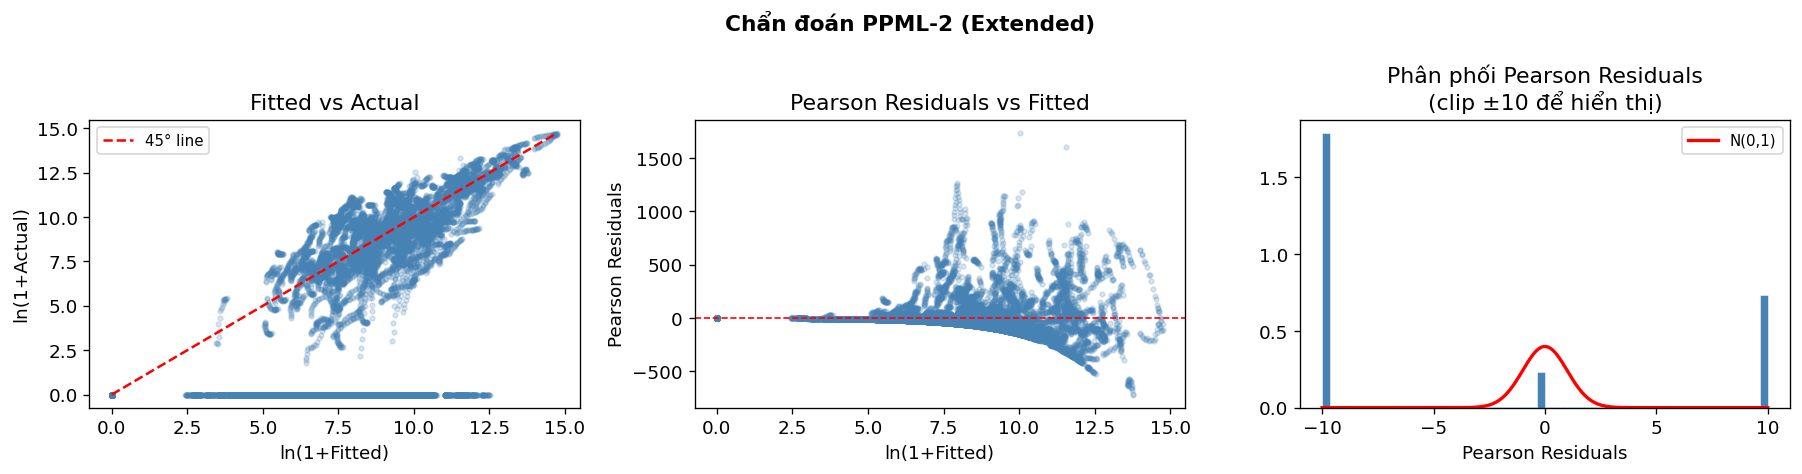

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chẩn đoán PPML-2 (Extended)', fontsize=13, fontweight='bold')

# Fitted vs Actual
fitted = res_p2.fittedvalues
ax = axes[0]
ax.scatter(np.log1p(fitted), np.log1p(y_p2), alpha=0.2, s=8, color='steelblue')
lim = max(np.log1p(fitted).max(), np.log1p(y_p2).max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='45° line')
ax.set_xlabel('ln(1+Fitted)')
ax.set_ylabel('ln(1+Actual)')
ax.set_title('Fitted vs Actual')
ax.legend(fontsize=9)

# Pearson residuals
ax = axes[1]
ax.scatter(np.log1p(fitted), res_p2.resid_pearson, alpha=0.2, s=8, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('ln(1+Fitted)')
ax.set_ylabel('Pearson Residuals')
ax.set_title('Pearson Residuals vs Fitted')

# Histogram Pearson residuals
ax = axes[2]
resid_p = res_p2.resid_pearson
resid_clipped = np.clip(resid_p, -10, 10)  # clip extreme for display
ax.hist(resid_clipped, bins=60, color='steelblue', edgecolor='white', lw=0.3, density=True)
x_range = np.linspace(-10, 10, 200)
ax.plot(x_range, stats.norm.pdf(x_range), 'r-', lw=2, label='N(0,1)')
ax.set_title('Phân phối Pearson Residuals\n(clip ±10 để hiển thị)')
ax.set_xlabel('Pearson Residuals')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../output/figures/ppml_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Xuất tất cả kết quả

In [16]:
base = '../output/tables/'

# Bảng hệ số chi tiết
all_tabs = pd.concat([tab_p1, tab_p2, tab_p3, tab_sur], ignore_index=True)
all_tabs.to_csv(f'{base}results_05_ppml_all.csv', index=False)

# Thống kê mô hình
model_stats = pd.DataFrame([
    {'Model':'Pooled OLS', 'N':int(pols_res.nobs),
     'R2':round(float(pols_res.rsquared),4), 'R2_within':'–',
     'FE':'Year','Obs_type':'migration>0'},
    {'Model':'FEM (Pair+Year FE)', 'N':int(fem_res.nobs),
     'R2':'–', 'R2_within':round(float(fem_res.rsquared_within),4),
     'FE':'Pair+Year','Obs_type':'migration>0'},
    {'Model':'REM', 'N':int(rem_res.nobs),
     'R2':round(float(rem_res.rsquared_overall),4), 'R2_within':round(float(rem_res.rsquared_within),4),
     'FE':'Year','Obs_type':'migration>0'},
    {'Model':'PPML-1 Core', 'N':len(y_p1),
     'R2':pseudo_r2(res_p1),'R2_within':'–',
     'FE':'Origin+Dest+Year','Obs_type':'migration>=0'},
    {'Model':'PPML-2 Extended', 'N':len(y_p2),
     'R2':pseudo_r2(res_p2),'R2_within':'–',
     'FE':'Origin+Dest+Year','Obs_type':'migration>=0'},
    {'Model':'PPML-3 No Year FE', 'N':len(y_p3),
     'R2':pseudo_r2(res_p3),'R2_within':'–',
     'FE':'Origin+Dest','Obs_type':'migration>=0'},
    {'Model':'PPML-SUR', 'N':len(y_sur),
     'R2':pseudo_r2(res_sur),'R2_within':'–',
     'FE':'Origin+Dest+Year','Obs_type':'migration>=0'},
])
model_stats.to_csv(f'{base}model_stats_05.csv', index=False)

print('✅ Đã lưu:')
print(f'   {base}results_05_ppml_all.csv')
print(f'   {base}model_stats_05.csv')
print(f'   {base}Table2_Gravity_Results.csv')
print(f'   {base}Table2_Gravity_Results.html')

✅ Đã lưu:
   ../output/tables/results_05_ppml_all.csv
   ../output/tables/model_stats_05.csv
   ../output/tables/Table2_Gravity_Results.csv
   ../output/tables/Table2_Gravity_Results.html


## 13. Kết luận & Diễn giải kết quả

### 13.1 So sánh với kỳ vọng lý thuyết

| Biến | Kỳ vọng | PPML-2 IRR | Nhận xét |
|------|---------|-----------|----------|
| `ln_gdppc_org` | − | Xem bảng | GDPpc cao → push yếu → ít di cư |
| `ln_gdppc_des` | + | Xem bảng | GDPpc cao → pull mạnh → nhiều di cư |
| `ln_pop_org`   | + | Xem bảng | Dân số lớn → pool di cư lớn hơn |
| `ln_dist`      | − | Xem bảng | Xa = tốn kém → ít di cư |
| `comlang_off`  | + | Xem bảng | Chung ngôn ngữ → giảm rào cản |
| `inflation_org`| + | Xem bảng | Lạm phát cao → bất ổn → push |
| `ln_internet`  | + | Xem bảng | Internet giảm chi phí tìm kiếm |
| `ln_disaster`  | + | Xem bảng | Thiên tai → di cư môi trường |

### 13.2 Ưu điểm PPML so với POLS/FEM
- Xử lý được **14,950 quan sát** (bao gồm zero flows) vs 8,308 của FEM
- Pseudo R² ≈ **0.83** >> R²_within FEM ≈ 0.46
- Ước lượng được **biến time-invariant** (dist, language, colony)
- PPML-SUR kiểm soát thêm **unobserved common factors** giữa các cặp

### 13.3 Bước tiếp theo
> ➡️ `06_feature_selection_bma_lasso.ipynb` – BMA & LASSO chọn biến tối ưu  
> ➡️ `07_spatial_econometrics_sdm.ipynb` – Kiểm tra hiệu ứng không gian  
> ➡️ `08_machine_learning_models.ipynb` – Random Forest, XGBoost  
> ➡️ `09_model_evaluation_comparison.ipynb` – So sánh & kết luận